# AutoML percentile-bias correction on M4 (XGBoost)

This notebook compares baseline AutoML forecasts vs. `percentile_correction=True` using M4 Weekly data.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from utilsforecast.losses import rmse

from datasetsforecast.m4 import M4, M4Info
from datasetsforecast.m3 import M3, M3Info
from mlforecast.auto import xgboost_space
import optuna

from utilsforecast.losses import rmse, mse, bias, mae

def eval_metrics(valid_df, preds_df, model_col: str):
    df = valid_df.merge(preds_df, on=["unique_id", "ds"], how="inner")
    return {
        "rows": len(df),
        "rmse": float(rmse(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "mse": float(mse(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "bias": float(bias(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "mae": float(mae(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
    }

def rmse_loss(df, train_df):  # train_df is unused here
    # df has columns: ["unique_id", "ds", "cutoff", "y", "model"]
    return rmse(df, models=["model"], id_col="unique_id", target_col="y")["model"].mean()

/Users/janrathfelder/miniconda3/envs/mlforecast-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

def rolling_holdout_splits(df, h, n_test_sets, time_col="ds"):
    # ensure datetime
    ds = pd.to_datetime(df[time_col])
    all_ds = sorted(ds.unique())
    max_ds = all_ds[-1]

    step = pd.Timedelta(days=1) 

    for k in range(n_test_sets):
        test_end = max_ds - k * h * step
        test_start = test_end - (h - 1) * step

        train = df[df[time_col] < test_start]
        test = df[(df[time_col] >= test_start) & (df[time_col] <= test_end)]

        yield k, train.reset_index(drop=True), test.reset_index(drop=True)


In [3]:
def tweedie_space(trial):
    params = xgboost_space(trial)
    params["objective"] = "reg:tweedie"
    params["tweedie_variance_power"] = 1.5
    params["eval_metric"] = "tweedie-nloglik@1.5"
    return params


In [30]:
from sklearn.preprocessing import FunctionTransformer
from mlforecast.target_transforms import LocalStandardScaler, GlobalSklearnTransformer

from mlforecast.lag_transforms import (RollingMean, ExponentiallyWeightedMean, ExpandingMax, ExpandingMin,
                                       RollingStd)

LAGS = [
 #   [1],
  #  [1, 2, 3],
  #  [1, 2, 3, 7],
  #  [1, 7, 14],
    [1, 7, 14, 28],
]

LAG_TRANSFORMS = [
    {1: [ExponentiallyWeightedMean(0.9),
         ExpandingMax(),
         ExpandingMin(),
         RollingStd(window_size=7, min_samples=1),
         RollingStd(window_size=14, min_samples=3),
         RollingMean(window_size=7, min_samples=1),
         RollingMean(window_size=14, min_samples=3)
         ]
     },
   # {
   #     1: [ExponentiallyWeightedMean(0.9)],
   #     7: [RollingMean(window_size=3, min_samples=1)],
   # },
]

DATE_FEATURES = ["year", "month", "week", "weekday"]  # standard calendar features

def my_init_config(trial):
    lags_idx = trial.suggest_int("lags_idx", 0, len(LAGS) - 1)
    ltfm_idx = trial.suggest_int("lag_tfms_idx", 0, len(LAG_TRANSFORMS) - 1)
    return {
        "target_transforms": None,   # no differencing
        "lags": LAGS[lags_idx],
        "lag_transforms": LAG_TRANSFORMS[ltfm_idx],
        "date_features": ["weekday", "week", "month"]

    }


In [5]:
from datasetsforecast.m5 import M5

Y_df, X_df, S_df = M5.load(directory="data")

In [6]:
all_ids = Y_df.unique_id.unique().tolist()

rng = np.random.default_rng(42)
sample_ids = rng.choice(all_ids, size=2000, replace=False).tolist()

df = Y_df[Y_df.unique_id.isin(sample_ids)]

df.shape

(3091837, 3)

In [ ]:
def my_fit_config(trial):
    return {
        "dropna": False,
    }
    
n_test_sets = 3
h = 7
n_windows = 3
num_samples = 2
step_size = 10

rmse_base_test = []
mse_base_test = []
mae_base_test = []
bias_base_test = []

rmse_corr_test = []
mse_corr_test = []
mae_corr_test = []
bias_corr_test = []

cv_rmse_normal_cv = []
cv_bias_normal_cv = []

cv_rmse_corr_cv = []
cv_bias_corr_cv = []

rmse_base_only_corrected_test = []
mse_base_only_corrected_test = []
mae_base_only_corrected_test = []
bias_base_only_corrected_test = []

rmse_corr_only_corrected_test = []
mse_corr_only_corrected_test = []
mae_corr_only_corrected_test = []
bias_corr_only_corrected_test = []

share_correction = []
p_val_cv = []

group_sum_records = []
group_correction_records = []
forecast_records = []
selected_percentile_records = []
fold_metric_records = []
train_history_records = []

for i, train_i, test_i in rolling_holdout_splits(df, h, n_test_sets):
    from mlforecast.auto import AutoMLForecast, AutoXGBoost, PredictionIntervals
    
    #auto_base = AutoMLForecast(
    #models={"xgb": AutoXGBoost(config=tweedie_space)},
    #freq="D",
    #init_config=my_init_config,
    #fit_config=my_fit_config,
    #reuse_cv_splits=True
    #)

    auto_corr = AutoMLForecast(
        models={"xgb": AutoXGBoost(config=tweedie_space)},
        #models={"xgb": AutoXGBoost()},
        freq="D",
        init_config=my_init_config,
        fit_config=my_fit_config,
        reuse_cv_splits=True,
        #season_length=7,
    )
    
    print(i, train_i.ds.min(), train_i.ds.max(), " | ", 
          test_i.ds.min(), test_i.ds.max())

    length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()

    good_ids = length_ids[length_ids.ds > 100].unique_id.unique()

    train_i = train_i[train_i.unique_id.isin(good_ids)].copy()
    test_i = test_i[test_i.unique_id.isin(good_ids)].copy()
    
    # Train base model:
    #auto_base.fit(
    #df=train_i,
    #n_windows=n_windows,
    #h=h,
    #num_samples=num_samples,
    #step_size=5,
    #loss=rmse_loss,
    #study_kwargs={"sampler": optuna.samplers.TPESampler()}
    # prediction_intervals=PredictionIntervals(n_windows=n_windows, h=h),
    #)

    #preds_base = auto_base.predict(h=test_i.ds.nunique())
    #metrics_base = eval_rmse_bias(test_i, preds_base, "xgb")
    
    # Train corrected model:
    auto_corr.percentile_correction_levels_ = list(range(1, 51))
    auto_corr.fit(
    df=train_i,
    n_windows=n_windows,
    h=h,
    num_samples=num_samples,
    step_size=step_size,
    prediction_intervals=PredictionIntervals(n_windows=3, h=h),
    percentile_correction=True,
    compute_corrected_cv_metrics=True,
    percentile_correction_mode="bias",
    percentile_correction_metric="rmse", 
    # percentile_correction_strict_bias=True,
    loss=rmse_loss,
    study_kwargs={"sampler": optuna.samplers.TPESampler()}
    )

    preds_corr = auto_corr.predict(h=test_i.ds.nunique())
    
    name = "xgb"
    corr = auto_corr.percentile_correction_[name]
    corr_ids = list(corr["id_to_col"].keys())
    raw_preds = auto_corr.models_[name].predict(
        h=test_i.ds.nunique(),
        level=corr["levels"],  # make sure percentile cols exist
    )
    
    metrics_corr = eval_metrics(test_i, preds_corr, "xgb")
    metrics_base = eval_metrics(test_i, raw_preds, "xgb")
    
    metrics_corr_only_corrected = eval_metrics(test_i[test_i.unique_id.isin(corr_ids)], 
                                                 preds_corr[preds_corr.unique_id.isin(corr_ids)], "xgb")
    metrics_base_only_corrected = eval_metrics(test_i[test_i.unique_id.isin(corr_ids)], 
                                                 raw_preds[raw_preds.unique_id.isin(corr_ids)], "xgb")
    
    rmse_base = metrics_base['rmse']
    mse_base = metrics_base['mse']
    mae_base = metrics_base['mae']
    bias_base = metrics_base['bias']
    
    rmse_corr = metrics_corr['rmse']
    mse_corr = metrics_corr['mse']
    mae_corr = metrics_corr['mae']
    bias_corr = metrics_corr['bias']
    
    rmse_base_only_corrected = metrics_base_only_corrected['rmse']
    mse_base_only_corrected = metrics_base_only_corrected['mse']
    mae_base_only_corrected = metrics_base_only_corrected['mae']
    bias_base_only_corrected = metrics_base_only_corrected['bias']
    
    rmse_corr = metrics_corr['rmse']
    mse_corr = metrics_corr['mse']
    mae_corr = metrics_corr['mae']
    bias_corr = metrics_corr['bias']
    
    rmse_corr_only_corrected = metrics_corr_only_corrected ['rmse']
    mse_corr_only_corrected = metrics_corr_only_corrected ['mse']
    mae_corr_only_corrected = metrics_corr_only_corrected ['mae']
    bias_corr_only_corrected = metrics_corr_only_corrected ['bias']
    
    cv_rmse_normal = auto_corr.cv_metrics_["xgb"]['rmse']
    cv_bias_normal = auto_corr.cv_metrics_["xgb"]['bias']
    
    cv_rmse_corr = auto_corr.cv_metrics_corrected_["xgb"]['rmse']
    cv_bias_corr = auto_corr.cv_metrics_corrected_["xgb"]['bias']
    
    #############
    # save outputs
    rmse_base_test.append(rmse_base)
    mse_base_test.append(mse_base)
    mae_base_test.append(mae_base)
    bias_base_test.append(bias_base)
    
    rmse_corr_test.append(rmse_corr)
    mse_corr_test.append(mse_corr)
    mae_corr_test.append(mae_corr)
    bias_corr_test.append(bias_corr)
    
    rmse_base_only_corrected_test.append(rmse_base_only_corrected)
    mse_base_only_corrected_test.append(mse_base_only_corrected)
    mae_base_only_corrected_test.append(mae_base_only_corrected)
    bias_base_only_corrected_test.append(bias_base_only_corrected)
    
    rmse_corr_only_corrected_test.append(rmse_corr_only_corrected)
    mse_corr_only_corrected_test.append(mse_corr_only_corrected)
    mae_corr_only_corrected_test.append(mae_corr_only_corrected)
    bias_corr_only_corrected_test.append(bias_corr_only_corrected)
    
    cv_rmse_normal_cv.append(cv_rmse_normal)
    cv_bias_normal_cv.append(cv_bias_normal)
    
    cv_rmse_corr_cv.append(cv_rmse_corr)
    cv_bias_corr_cv.append(cv_bias_corr)
    ###############
    # Get base and corrected forecast from correction model:
    

    # raw predictions WITH the needed percentile columns
    #raw_preds = auto_corr.models_[name].predict(
    #    h=test_i.ds.nunique(),
    #    level=corr["levels"],  # make sure percentile cols exist
    #)

    # corrected predictions (auto_corr.predict applies correction)
    preds_optimal = auto_corr.predict(h=test_i.ds.nunique())
    ###############
    preds_all = raw_preds.merge(preds_optimal, on=['ds', 'unique_id'])
    
    corr_ids_str = set(map(str, corr_ids))

    selected_map_df = pd.DataFrame(
        [{'unique_id': str(k), 'selected_col': v} for k, v in corr['id_to_col'].items()]
    )
    if not selected_map_df.empty:
        sel_parts = selected_map_df['selected_col'].str.extract(
            r'^(?P<model>.+)-(?P<selected_side>lo|hi)-(?P<selected_percentile>\d+(?:\.\d+)?)$'
        )
        selected_map_df = pd.concat([selected_map_df, sel_parts], axis=1)
        selected_map_df['selected_percentile'] = pd.to_numeric(
            selected_map_df['selected_percentile'], errors='coerce'
        )
    else:
        selected_map_df = pd.DataFrame(
            columns=['unique_id', 'selected_col', 'model', 'selected_side', 'selected_percentile']
        )

    train_stats = train_i.groupby('unique_id', as_index=False).agg(
        train_mean_sales=('y', 'mean'),
        train_total_sales=('y', 'sum'),
        train_n_obs=('y', 'size'),
    )
    quantiles = train_stats['train_mean_sales'].quantile([0.05, 0.2, 0.4, 0.6, 0.8, 0.95]).values
    q05, q20, q40, q60, q80, q95 = quantiles

    def assign_sales_group(x):
        if x <= q05:
            return 'G0_bottom5'
        if x <= q20:
            return 'G1_low_5_to_20'
        if x <= q40:
            return 'G2_low'
        if x <= q60:
            return 'G3_mid'
        if x <= q80:
            return 'G4_high'
        if x <= q95:
            return 'G5_top20_to_5'
        return 'G6_top5'

    group_order = ['G0_bottom5', 'G1_low_5_to_20', 'G2_low', 'G3_mid', 'G4_high', 'G5_top20_to_5', 'G6_top5']
    train_stats['sales_group'] = train_stats['train_mean_sales'].apply(assign_sales_group)
    train_stats['unique_id'] = train_stats['unique_id'].astype(str)

    correction_by_id = train_stats[['unique_id', 'sales_group', 'train_mean_sales', 'train_total_sales', 'train_n_obs']].copy()
    correction_by_id['is_corrected'] = correction_by_id['unique_id'].isin(corr_ids_str)
    correction_by_id = correction_by_id.merge(
        selected_map_df[['unique_id', 'selected_col', 'selected_side', 'selected_percentile']],
        on='unique_id',
        how='left',
    )
    correction_by_id['fold'] = i
    group_correction_records.append(correction_by_id)

    selected_map_fold = selected_map_df.copy()
    selected_map_fold['fold'] = i
    selected_percentile_records.append(selected_map_fold)

    train_hist_fold = train_stats.copy()
    train_hist_fold['fold'] = i
    train_history_records.append(train_hist_fold)

    raw_for_eval = raw_preds[['unique_id', 'ds', 'xgb']].rename(columns={'xgb': 'raw_pred'})
    corr_for_eval = preds_corr[['unique_id', 'ds', 'xgb']].rename(columns={'xgb': 'corrected_pred'})
    preds_compare = test_i[['unique_id', 'ds', 'y']].copy()
    preds_compare['unique_id'] = preds_compare['unique_id'].astype(str)
    preds_compare = preds_compare.merge(raw_for_eval, on=['unique_id', 'ds'], how='left')
    preds_compare = preds_compare.merge(corr_for_eval, on=['unique_id', 'ds'], how='left')
    preds_compare = preds_compare.merge(
        correction_by_id[['unique_id', 'sales_group', 'is_corrected', 'selected_col', 'selected_side', 'selected_percentile']],
        on='unique_id',
        how='left',
    )
    preds_compare['raw_abs_err'] = (preds_compare['raw_pred'] - preds_compare['y']).abs()
    preds_compare['corrected_abs_err'] = (preds_compare['corrected_pred'] - preds_compare['y']).abs()
    preds_compare['fold'] = i
    forecast_records.append(preds_compare)

    per_id_horizon = preds_compare.groupby(['sales_group', 'unique_id'], observed=True, as_index=False).agg(
        true_sum=('y', 'sum'),
        raw_sum=('raw_pred', 'sum'),
        corrected_sum=('corrected_pred', 'sum'),
    )

    group_fold = per_id_horizon.groupby('sales_group', observed=True, as_index=False).agg(
        true_sum=('true_sum', 'mean'),
        raw_sum=('raw_sum', 'mean'),
        corrected_sum=('corrected_sum', 'mean'),
    )

    group_metrics = preds_compare.groupby('sales_group', observed=True, as_index=False).agg(
        correction_coverage=('is_corrected', 'mean'),
        improved_share=('corrected_abs_err', lambda s: float((s.values < preds_compare.loc[s.index, 'raw_abs_err'].values).mean())),
        raw_rmse=('raw_pred', lambda s: float(np.sqrt(np.mean((s - preds_compare.loc[s.index, 'y']) ** 2)))),
        corrected_rmse=('corrected_pred', lambda s: float(np.sqrt(np.mean((s - preds_compare.loc[s.index, 'y']) ** 2)))),
        raw_bias=('raw_pred', lambda s: float((s - preds_compare.loc[s.index, 'y']).mean())),
        corrected_bias=('corrected_pred', lambda s: float((s - preds_compare.loc[s.index, 'y']).mean())),
    )
    group_fold = group_fold.merge(group_metrics, on='sales_group', how='left')
    group_fold['raw_gap'] = group_fold['raw_sum'] - group_fold['true_sum']
    group_fold['corrected_gap'] = group_fold['corrected_sum'] - group_fold['true_sum']
    base_gap_abs = group_fold['raw_gap'].abs().replace(0, np.nan)
    group_fold['adjustment_share'] = (group_fold['corrected_sum'] - group_fold['raw_sum']).abs() / base_gap_abs
    group_fold['raw_to_true_ratio'] = np.where(group_fold['true_sum'] != 0, group_fold['raw_sum'] / group_fold['true_sum'], np.nan)
    group_fold['corrected_to_true_ratio'] = np.where(group_fold['true_sum'] != 0, group_fold['corrected_sum'] / group_fold['true_sum'], np.nan)
    group_fold['raw_pct_error'] = np.where(group_fold['true_sum'] != 0, group_fold['raw_gap'] / group_fold['true_sum'], np.nan)
    group_fold['corrected_pct_error'] = np.where(group_fold['true_sum'] != 0, group_fold['corrected_gap'] / group_fold['true_sum'], np.nan)
    group_fold['abs_gap_improvement'] = group_fold['raw_gap'].abs() - group_fold['corrected_gap'].abs()
    group_fold['rmse_improvement'] = group_fold['raw_rmse'] - group_fold['corrected_rmse']
    group_fold['bias_abs_improvement'] = group_fold['raw_bias'].abs() - group_fold['corrected_bias'].abs()
    group_fold['fold'] = i
    group_fold['sales_group'] = pd.Categorical(group_fold['sales_group'], categories=group_order, ordered=True)
    group_fold = group_fold.sort_values('sales_group').reset_index(drop=True)
    group_sum_records.append(group_fold)

    fold_metric_records.append({
        'fold': i,
        'n_ids_train': int(train_i['unique_id'].nunique()),
        'n_ids_corrected': int(len(corr_ids_str)),
        'share_ids_corrected': float(len(corr_ids_str) / max(train_i['unique_id'].nunique(), 1)),
        'rmse_raw': float(metrics_base['rmse']),
        'rmse_corrected': float(metrics_corr['rmse']),
        'bias_raw': float(metrics_base['bias']),
        'bias_corrected': float(metrics_corr['bias']),
    })

    preds_all = preds_all[preds_all.unique_id.astype(str).isin(corr_ids_str)]
    
    preds_all = preds_all.merge(test_i, on=['ds', 'unique_id'])

    preds_all['res_base'] = abs(preds_all.xgb_x - preds_all.y)
    preds_all['res_best'] = abs(preds_all.xgb_y - preds_all.y)

    preds_all['flag'] = np.where(preds_all.res_best < preds_all.res_base, 1, 0)
    share_correction.append(preds_all['flag'].mean())
    #############
    # Run t-test:
    t_stat, p_val = stats.ttest_ind(preds_all.xgb_x, 
                                preds_all.xgb_y, 
                                equal_var=True)  
    p_val_cv.append(p_val)

0 2011-01-29 00:00:00 2016-06-12 00:00:00  |  2016-06-13 00:00:00 2016-06-19 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_71110/1221747921.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
[I 2026-06-27 20:11:51,189] A new study created in memory with name: no-name-710a77e0-27a9-47f6-b5ba-f25e3eee2d27
[I 2026-06-27 20:12:16,931] Trial 0 finished with value: 1.711936593055725 and parameters: {'n_estimators': 291, 'max_depth': 7, 'learning_rate': 0.0020718642537713673, 'subsample': 0.34535882722075256, 'colsample_bytree': 0.6319182056089934, 'reg_lambda': 9.690052717089826e-07, 'reg_alpha': 5.7940551338237966e-08, 'min_child_weight': 8, 'lags_idx': 0, 'lag_tfms_idx': 0}. Best is trial 0 with value: 1.711936593055725.
[I 2026-06-27 20:12:44,485] Trial 1 finished with value: 1.55270516872406 

1 2011-01-29 00:00:00 2016-06-05 00:00:00  |  2016-06-06 00:00:00 2016-06-12 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_71110/1221747921.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
[I 2026-06-27 20:18:02,728] A new study created in memory with name: no-name-9d58adb7-af7d-422d-9a20-51aeb8c9dd49
[I 2026-06-27 20:18:37,005] Trial 0 finished with value: 1.2944003343582153 and parameters: {'n_estimators': 438, 'max_depth': 7, 'learning_rate': 0.017611773765839063, 'subsample': 0.6483776245045237, 'colsample_bytree': 0.37426589029687346, 'reg_lambda': 0.0010117458454756726, 'reg_alpha': 0.00014195522563718716, 'min_child_weight': 6, 'lags_idx': 0, 'lag_tfms_idx': 0}. Best is trial 0 with value: 1.2944003343582153.
[I 2026-06-27 20:20:10,188] Trial 1 finished with value: 1.39413022994995

2 2011-01-29 00:00:00 2016-05-29 00:00:00  |  2016-05-30 00:00:00 2016-06-05 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_71110/1221747921.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
[I 2026-06-27 20:26:29,204] A new study created in memory with name: no-name-95ff8711-79a8-403b-85f3-b9f098eff41f
[I 2026-06-27 20:27:46,794] Trial 0 finished with value: 1.413488745689392 and parameters: {'n_estimators': 644, 'max_depth': 10, 'learning_rate': 0.0029837343688420477, 'subsample': 0.9103851688921059, 'colsample_bytree': 0.37716578836055814, 'reg_lambda': 4.178243628932213e-05, 'reg_alpha': 1.5504497695106952e-06, 'min_child_weight': 8, 'lags_idx': 0, 'lag_tfms_idx': 0}. Best is trial 0 with value: 1.413488745689392.
[I 2026-06-27 20:28:04,927] Trial 1 finished with value: 1.27234518527984

In [34]:
metrics_corr_only_corrected

{'rows': 4599,
 'rmse': 1.2216122150421143,
 'mse': 8.03741455078125,
 'bias': -0.0030513310339301825,
 'mae': 0.9757470488548279}

In [35]:
metrics_base_only_corrected

{'rows': 4599,
 'rmse': 1.1808801889419556,
 'mse': 6.014692306518555,
 'bias': 0.1379147469997406,
 'mae': 0.9944971799850464}

In [36]:
import numpy as np
count = np.sum(np.array(bias_corr_only_corrected_test) 
               < np.array(bias_base_only_corrected_test))
count / len(bias_base_only_corrected_test)


np.float64(0.6666666666666666)

In [37]:
count = np.sum(np.array(rmse_corr_only_corrected_test) 
               < np.array(rmse_base_only_corrected_test))
count / len(rmse_base_only_corrected_test)

np.float64(0.3333333333333333)

In [38]:
count = np.sum(np.array(mae_corr_only_corrected_test) 
               < np.array(mae_base_only_corrected_test))
count / len(mae_base_only_corrected_test)

np.float64(1.0)

In [39]:
count = np.sum(np.array(mse_corr_only_corrected_test) 
               < np.array(mse_base_only_corrected_test))
count / len(mse_base_only_corrected_test)

np.float64(0.3333333333333333)

In [40]:
print(np.mean(rmse_base_only_corrected_test),
      np.mean(rmse_corr_only_corrected_test),
      
      
np.mean(np.abs(bias_base_only_corrected_test)),
np.mean(np.abs(bias_corr_only_corrected_test))
)

1.3434960047403972 1.2240495284398396 0.29506031175454456 0.03118569147773087


In [41]:
share_correction

[np.float64(0.710891700092564),
 np.float64(0.6712983065566652),
 np.float64(0.6897151554685801)]

In [42]:
import numpy as np
print(
    np.mean(share_correction),
    np.std(share_correction),
    len(share_correction)
)


0.6906350540392697 0.016177017915495733 3


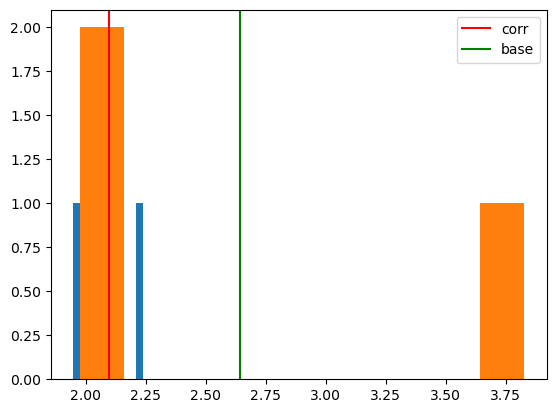

In [43]:
import matplotlib.pyplot as plt

plt.hist(cv_rmse_corr_cv)
plt.axvline(np.mean(cv_rmse_corr_cv), color='red', label='corr')
plt.hist(cv_rmse_normal_cv)
plt.axvline(np.mean(cv_rmse_normal_cv),  color='green', label='base')
plt.legend()
plt.show()

In [44]:
np.mean(rmse_corr_test) / np.mean(rmse_base_test) - 1

np.float64(-0.04130213877416011)

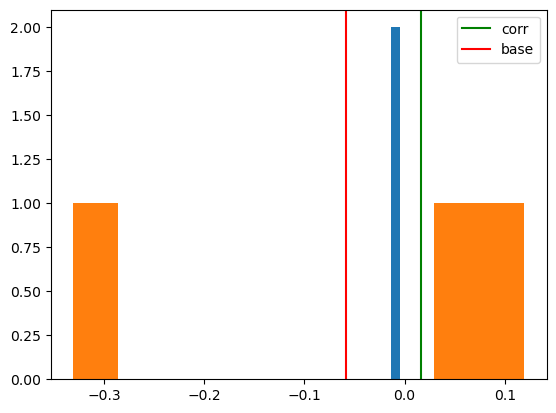

In [45]:
plt.hist(bias_corr_test)
plt.axvline(np.mean(bias_corr_test), label='corr', color='green')
plt.hist(bias_base_test)
plt.axvline(np.mean(bias_base_test), label='base', color='red')
plt.legend()
plt.show()

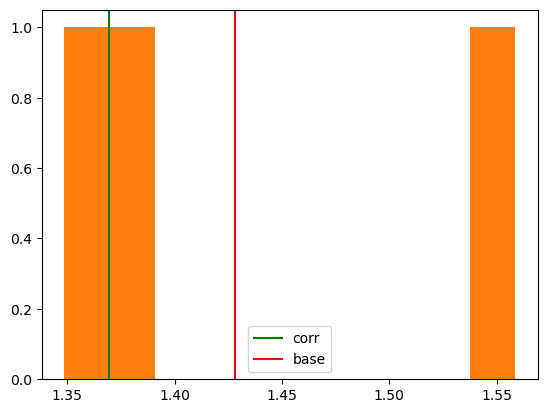

In [46]:
plt.hist(rmse_corr_test)
plt.axvline(np.mean(rmse_corr_test), label='corr', color='green')
plt.hist(rmse_base_test)
plt.axvline(np.mean(rmse_base_test), label='base', color='red')
plt.legend()
plt.show()

In [47]:
count = np.sum(np.array(mae_corr_test) 
               < np.array(mae_base_test))
count / len(bias_base_only_corrected_test)

np.float64(1.0)

In [48]:
print(np.mean(mae_corr_test),
np.mean((mae_base_test)))

1.1272224187850952 1.2036832571029663


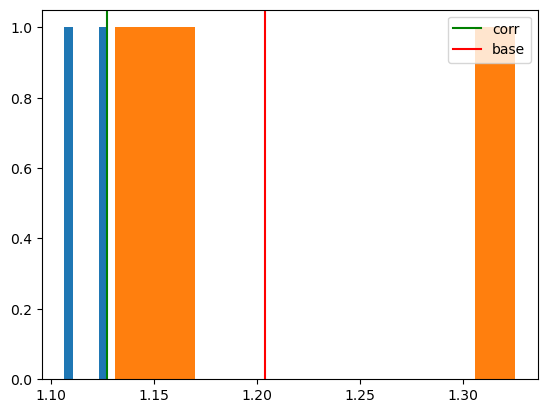

In [49]:
plt.hist(mae_corr_test)
plt.axvline(np.mean(mae_corr_test), label='corr', color='green')
plt.hist(mae_base_test)
plt.axvline(np.mean(mae_base_test), label='base', color='red')
plt.legend()
plt.show()

/Users/janrathfelder/miniconda3/envs/mlforecast-dev/lib/python3.10/site-packages/utilsforecast/processing.py:152: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
/Users/janrathfelder/miniconda3/envs/mlforecast-dev/lib/python3.10/site-packages/utilsforecast/processing.py:152: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
/Users/janrathfelder/miniconda3/envs/mlforecast-dev/lib/python3.10/site-packages/utilsforecast/processing.py:152: PerformanceWarning: DataFrame is highly fragmented.  This is u

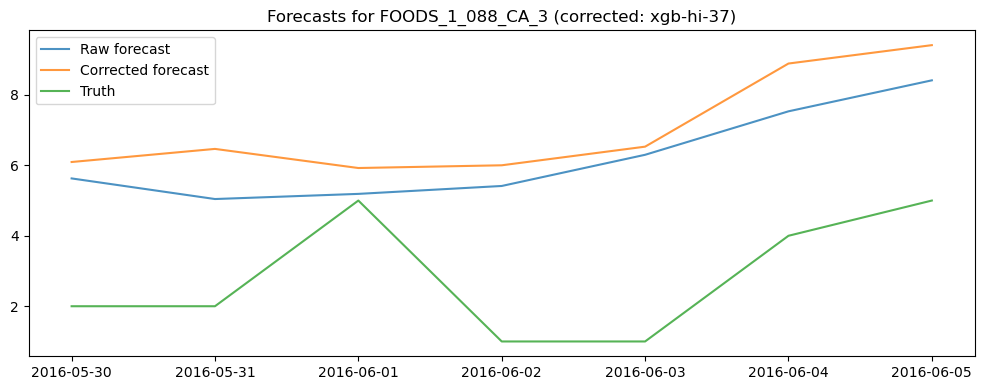

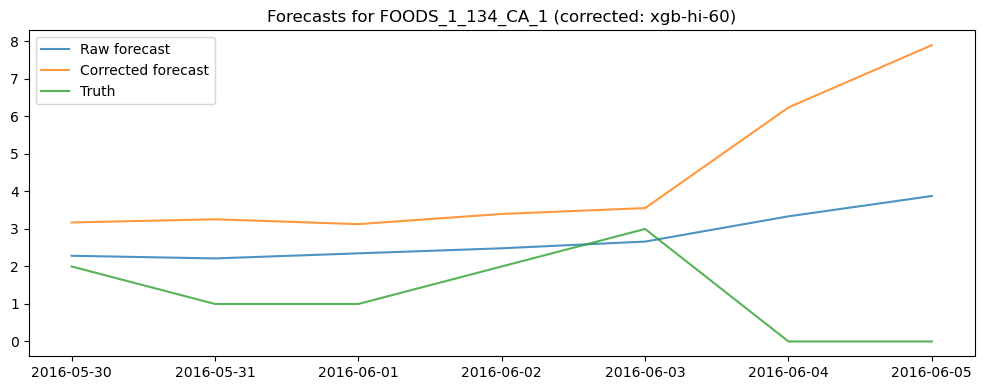

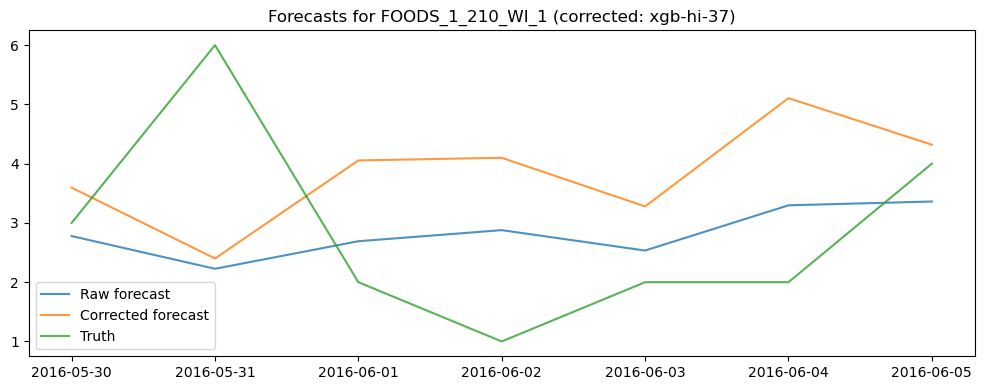

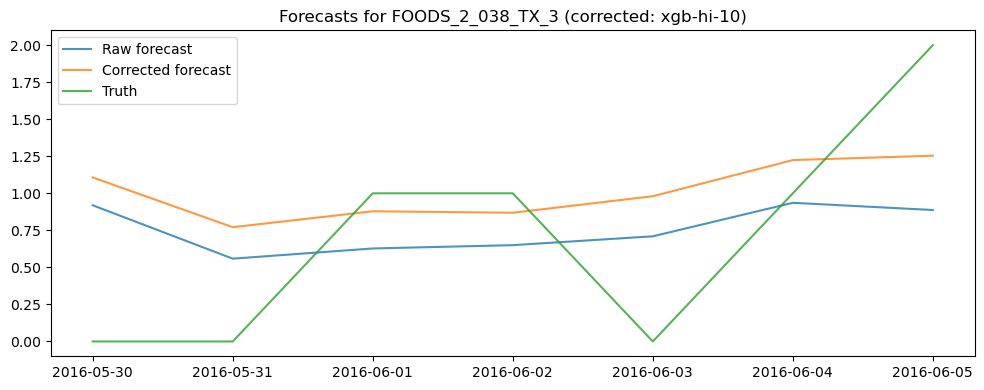

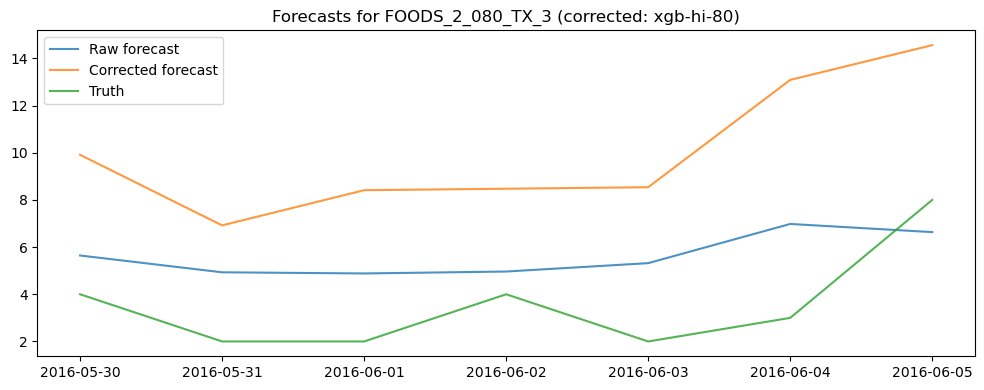

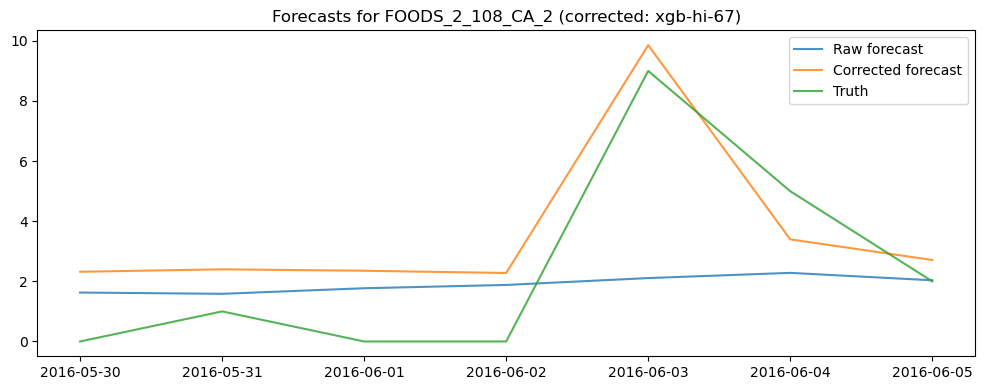

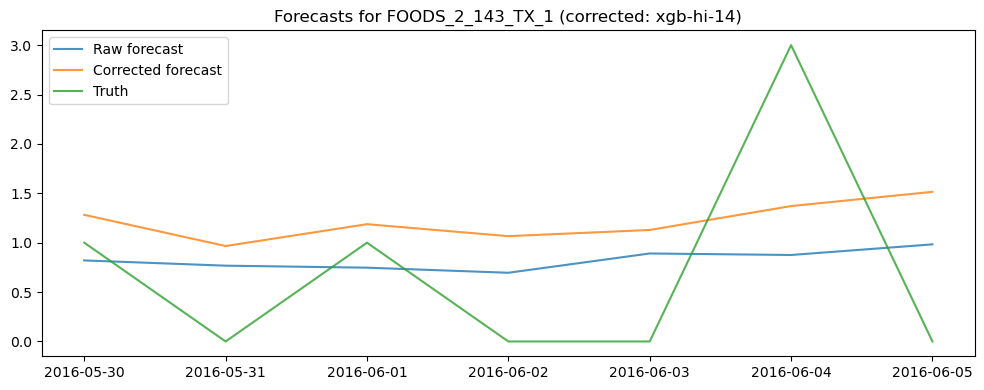

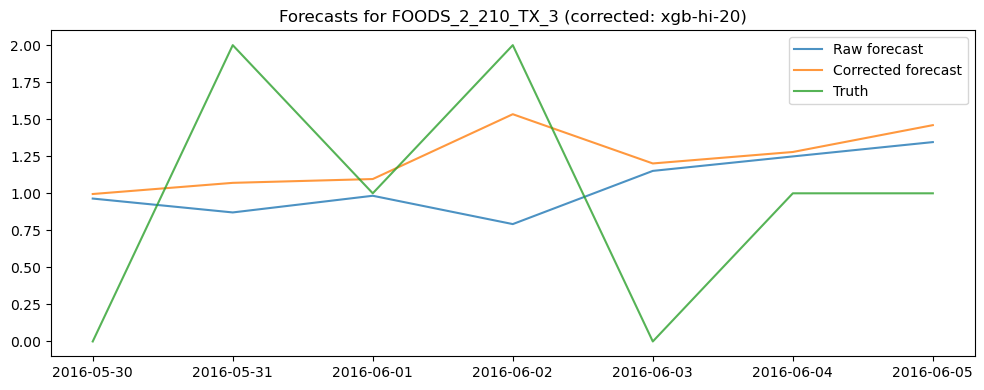

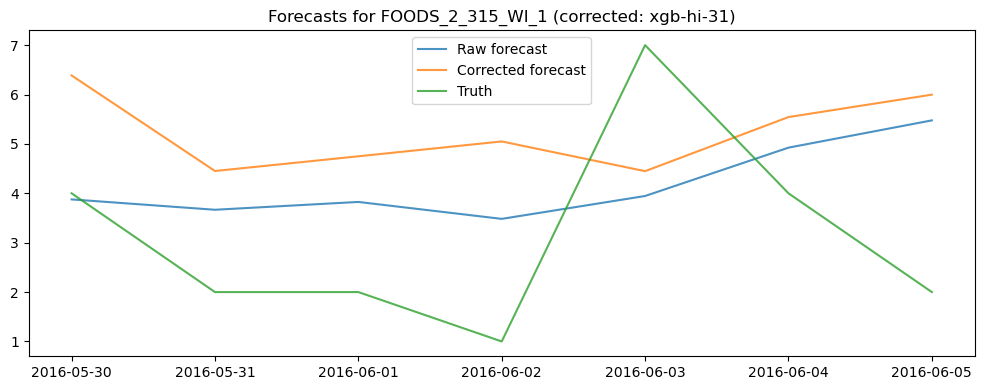

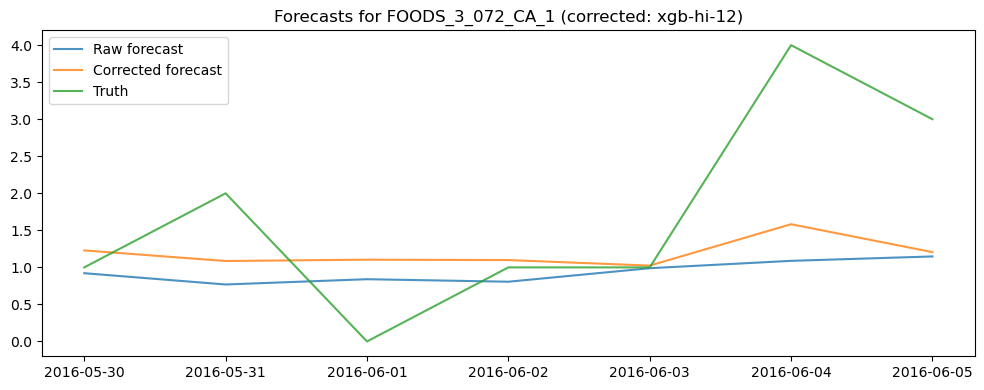

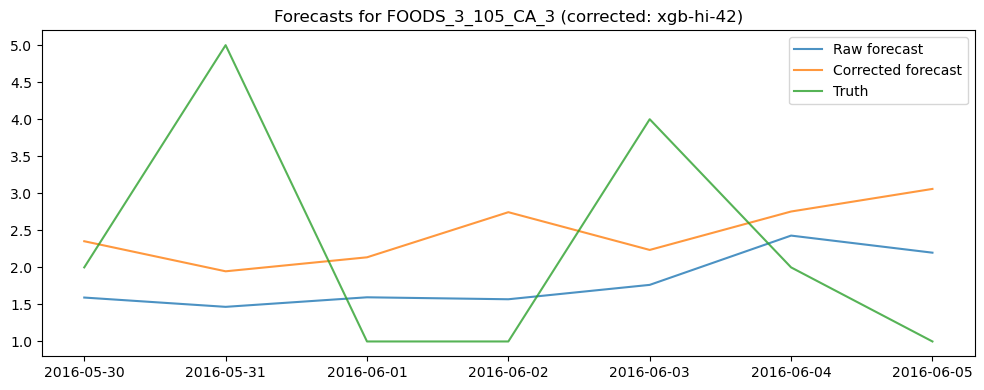

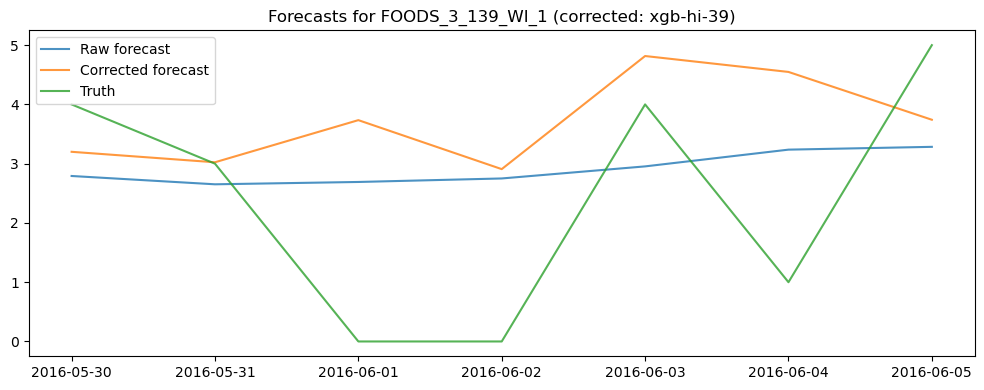

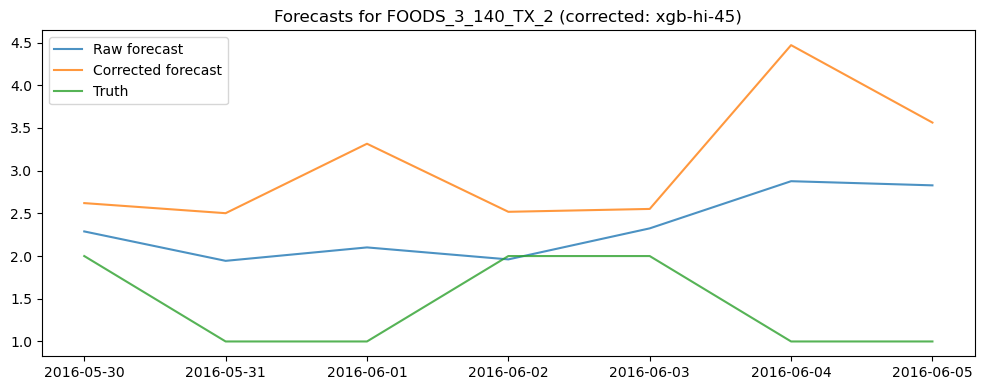

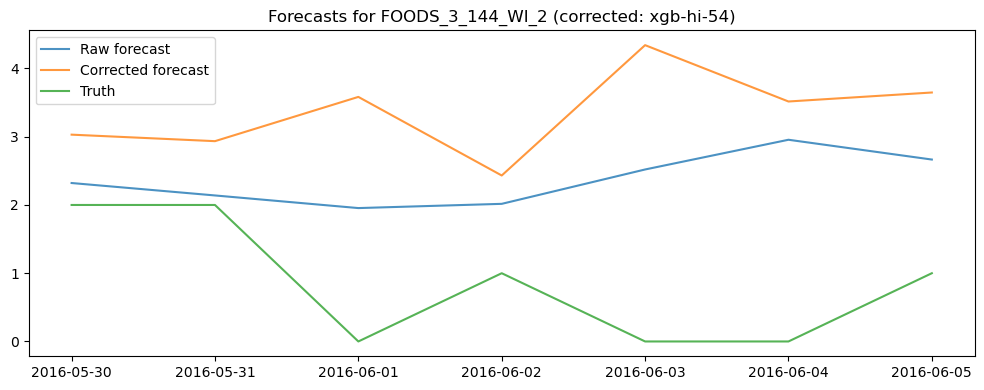

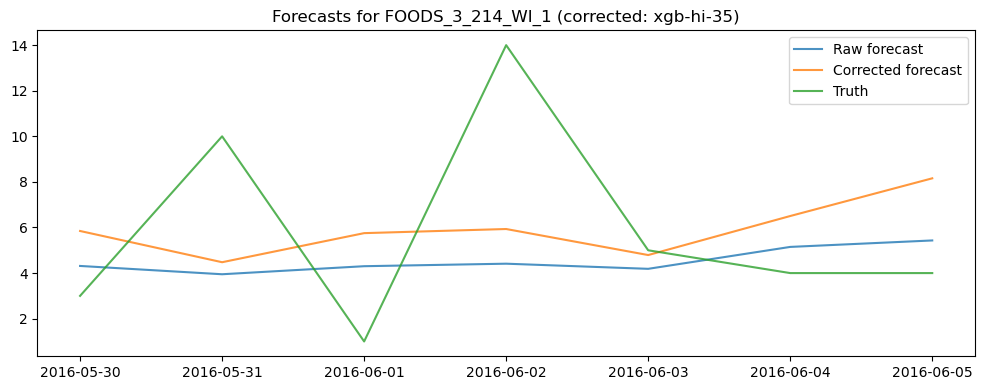

In [50]:
import matplotlib.pyplot as plt

name = "xgb"
corr = auto_corr.percentile_correction_[name]
corr_ids = list(corr["id_to_col"].keys())

# raw predictions WITH the needed percentile columns
raw_preds = auto_corr.models_[name].predict(
    h=h,
    level=corr["levels"],  # make sure percentile cols exist
)

# corrected predictions (auto_corr.predict applies correction)
corr_preds = auto_corr.predict(h=h)

for uid in corr_ids[0:15]:
    raw_uid = raw_preds[raw_preds["unique_id"] == uid]
    corr_uid = corr_preds[corr_preds["unique_id"] == uid]
    test_uid = test_i[test_i["unique_id"] == uid]
    #train_uid = train_i[train_i["unique_id"] == uid]
    

    plt.figure(figsize=(10, 4))
    #plt.plot(valid_uid["ds"], valid_uid["y"], label="Actuals (valid.y)", color="black", alpha=0.8)
    plt.plot(raw_uid["ds"], raw_uid[name], label="Raw forecast", alpha=0.8)
    plt.plot(corr_uid["ds"], corr_uid[name], label="Corrected forecast", alpha=0.8)
    plt.plot(test_uid["ds"], test_uid['y'], label="Truth", alpha=0.8)
    #plt.plot(train_uid["ds"], train_uid['y'], label="Truth", alpha=0.8)
    plt.title(f"Forecasts for {uid} (corrected: {corr['id_to_col'][uid]})")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [51]:
raw_preds.head(1)

,unique_id,ds,xgb,xgb-lo-80,xgb-lo-77,xgb-lo-76,xgb-lo-75,xgb-lo-74,xgb-lo-73,xgb-lo-72,...,xgb-hi-68,xgb-hi-69,xgb-hi-70,xgb-hi-72,xgb-hi-73,xgb-hi-74,xgb-hi-75,xgb-hi-76,xgb-hi-77,xgb-hi-80
0,FOODS_1_004_TX_2,2016-05-30,5.356644,2.051354,2.252756,2.31989,2.387024,2.454158,2.521292,2.588426,...,7.856326,7.92346,7.990594,8.124862,8.191996,8.25913,8.326264,8.393398,8.460532,8.661935


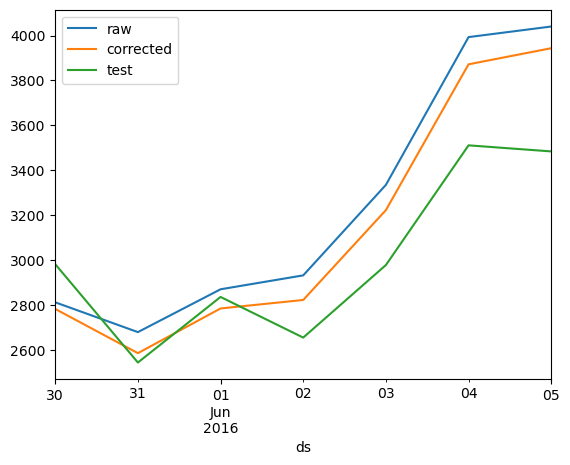

In [52]:
raw_preds.groupby('ds').xgb.sum().plot(label='raw')
corr_preds.groupby('ds').xgb.sum().plot(label='corrected')
test_i.groupby('ds').y.sum().plot(label='test')
plt.legend()
plt.show()

## Group-level diagnostics (M4)
Diagnostics mirroring the grocery and M5 notebooks: grouped forecast sums, correction coverage, RMSE/bias by sales segment, and selected percentiles.


In [96]:
group_summary_df = pd.concat(group_sum_records, ignore_index=True) if len(group_sum_records) else pd.DataFrame()
group_correction_df = pd.concat(group_correction_records, ignore_index=True) if len(group_correction_records) else pd.DataFrame()
forecast_eval_df = pd.concat(forecast_records, ignore_index=True) if len(forecast_records) else pd.DataFrame()
selected_percentiles_df = pd.concat(selected_percentile_records, ignore_index=True) if len(selected_percentile_records) else pd.DataFrame()
fold_metrics_df = pd.DataFrame(fold_metric_records)
train_history_df = pd.concat(train_history_records, ignore_index=True) if len(train_history_records) else pd.DataFrame()

group_summary = pd.DataFrame()
if not group_summary_df.empty:
    group_summary = group_summary_df.groupby('sales_group', observed=True, as_index=False).agg({
        'true_sum': 'mean',
        'raw_sum': 'mean',
        'corrected_sum': 'mean',
        'raw_gap': 'mean',
        'corrected_gap': 'mean',
        'correction_coverage': 'mean',
        'adjustment_share': 'mean',
        'improved_share': 'mean',
        'raw_to_true_ratio': 'mean',
        'corrected_to_true_ratio': 'mean',
        'raw_pct_error': 'mean',
        'corrected_pct_error': 'mean',
        'abs_gap_improvement': 'mean',
        'raw_rmse': 'mean',
        'corrected_rmse': 'mean',
        'raw_bias': 'mean',
        'corrected_bias': 'mean',
        'rmse_improvement': 'mean',
        'bias_abs_improvement': 'mean',
    })

    overall = pd.DataFrame([{
        'sales_group': 'ALL',
        'true_sum': group_summary_df['true_sum'].mean(),
        'raw_sum': group_summary_df['raw_sum'].mean(),
        'corrected_sum': group_summary_df['corrected_sum'].mean(),
        'raw_gap': group_summary_df['raw_gap'].mean(),
        'corrected_gap': group_summary_df['corrected_gap'].mean(),
        'correction_coverage': group_summary_df['correction_coverage'].mean(),
        'adjustment_share': group_summary_df['adjustment_share'].mean(),
        'improved_share': group_summary_df['improved_share'].mean(),
        'raw_to_true_ratio': group_summary_df['raw_to_true_ratio'].mean(),
        'corrected_to_true_ratio': group_summary_df['corrected_to_true_ratio'].mean(),
        'raw_pct_error': group_summary_df['raw_pct_error'].mean(),
        'corrected_pct_error': group_summary_df['corrected_pct_error'].mean(),
        'abs_gap_improvement': group_summary_df['abs_gap_improvement'].mean(),
        'raw_rmse': group_summary_df['raw_rmse'].mean(),
        'corrected_rmse': group_summary_df['corrected_rmse'].mean(),
        'raw_bias': group_summary_df['raw_bias'].mean(),
        'corrected_bias': group_summary_df['corrected_bias'].mean(),
        'rmse_improvement': group_summary_df['rmse_improvement'].mean(),
        'bias_abs_improvement': group_summary_df['bias_abs_improvement'].mean(),
    }])

    group_summary = pd.concat([group_summary, overall], ignore_index=True)
    display(group_summary)

display(fold_metrics_df)
display(group_correction_df.head())
display(selected_percentiles_df.head())


,sales_group,true_sum,raw_sum,corrected_sum,raw_gap,corrected_gap,correction_coverage,adjustment_share,improved_share,raw_to_true_ratio,corrected_to_true_ratio,raw_pct_error,corrected_pct_error,abs_gap_improvement,raw_rmse,corrected_rmse,raw_bias,corrected_bias,rmse_improvement,bias_abs_improvement
0,G0_bottom5,0.793333,1.908534,1.081411,1.115200,0.288077,0.623333,0.750559,0.537143,2.462626,1.378209,1.462626,0.378208,0.827123,0.426578,0.414240,0.159314,0.041154,0.012338,0.118160
1,G1_low_5_to_20,1.687778,2.527942,1.951267,0.840164,0.263489,0.485556,0.752377,0.394444,1.495096,1.154680,0.495096,0.154680,0.576675,0.616091,0.611775,0.120023,0.037641,0.004316,0.082382
2,G2_low,2.930833,3.665010,3.257670,0.734177,0.326836,0.344167,0.687323,0.246190,1.248541,1.110597,0.248540,0.110597,0.394769,0.823966,0.825623,0.104882,0.046691,-0.001657,0.056396
3,G3_mid,4.958333,5.527566,5.378999,0.569233,0.420666,0.258333,0.192648,0.148333,1.118254,1.087527,0.118254,0.087527,0.139798,1.091248,1.125571,0.081319,0.060095,-0.034323,0.019971
4,G4_high,9.170834,9.479365,9.411612,0.308532,0.240778,0.245000,0.131728,0.122024,1.036946,1.029251,0.036946,0.029251,0.002446,1.678463,1.721903,0.044076,0.034397,-0.043440,0.000349
5,G5_top20_to_5,18.184443,18.856707,18.497864,0.672264,0.313420,0.234444,0.748844,0.111905,1.036678,1.016798,0.036678,0.016798,0.140416,2.436201,2.493449,0.096038,0.044774,-0.057248,0.020060
6,G6_top5,81.250000,79.361397,79.793640,-1.888606,-1.456357,0.273333,0.455915,0.129524,0.976088,0.981808,-0.023912,-0.018192,0.779035,8.118106,8.187789,-0.269801,-0.208051,-0.069683,0.111291
7,ALL,16.996508,17.332359,17.053209,0.335852,0.056701,0.352024,0.531342,0.241366,1.339176,1.108410,0.339175,0.108410,0.408609,2.170093,2.197193,0.047979,0.008100,-0.027100,0.058373


,fold,n_ids_train,n_ids_corrected,share_ids_corrected,rmse_raw,rmse_corrected,bias_raw,bias_corrected
0,0,2000,641,0.3205,1.306751,1.319727,0.111697,0.049780
1,1,2000,723,0.3615,1.383243,1.390814,0.179985,0.125039
2,2,2000,570,0.2850,1.345691,1.360841,-0.072861,-0.078057


,unique_id,sales_group,train_mean_sales,train_total_sales,train_n_obs,is_corrected,selected_col,selected_side,selected_percentile,fold
0,FOODS_1_001_CA_1,G6_top5,NaN,0.0,0,False,NaN,NaN,NaN,0
1,FOODS_1_001_CA_2,G6_top5,NaN,0.0,0,False,NaN,NaN,NaN,0
2,FOODS_1_001_CA_3,G6_top5,NaN,0.0,0,False,NaN,NaN,NaN,0
3,FOODS_1_001_CA_4,G6_top5,NaN,0.0,0,False,NaN,NaN,NaN,0
4,FOODS_1_001_TX_1,G6_top5,NaN,0.0,0,False,NaN,NaN,NaN,0


,unique_id,selected_col,model,selected_side,selected_percentile,fold
0,FOODS_1_070_WI_3,xgb-hi-19,xgb,hi,19,0
1,FOODS_1_107_TX_1,xgb-hi-6,xgb,hi,6,0
2,FOODS_1_134_CA_1,xgb-hi-32,xgb,hi,32,0
3,FOODS_1_200_CA_1,xgb-hi-20,xgb,hi,20,0
4,FOODS_2_034_WI_3,xgb-hi-16,xgb,hi,16,0


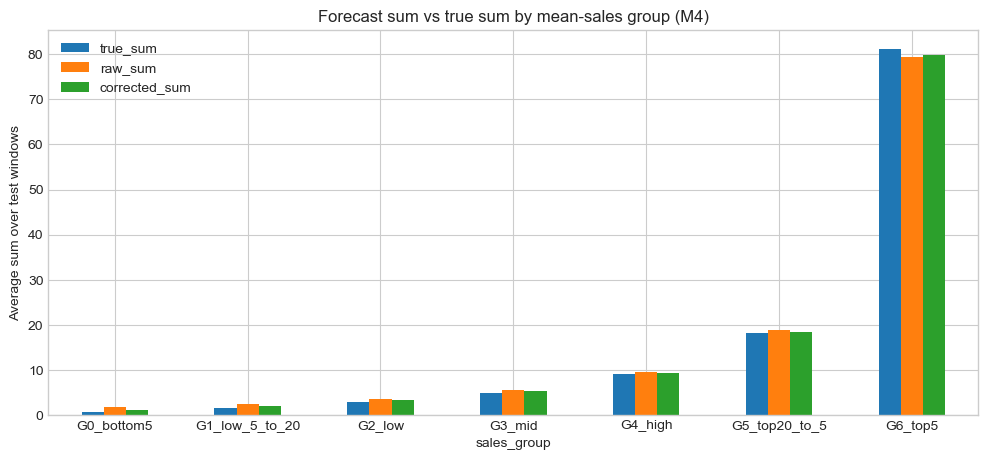

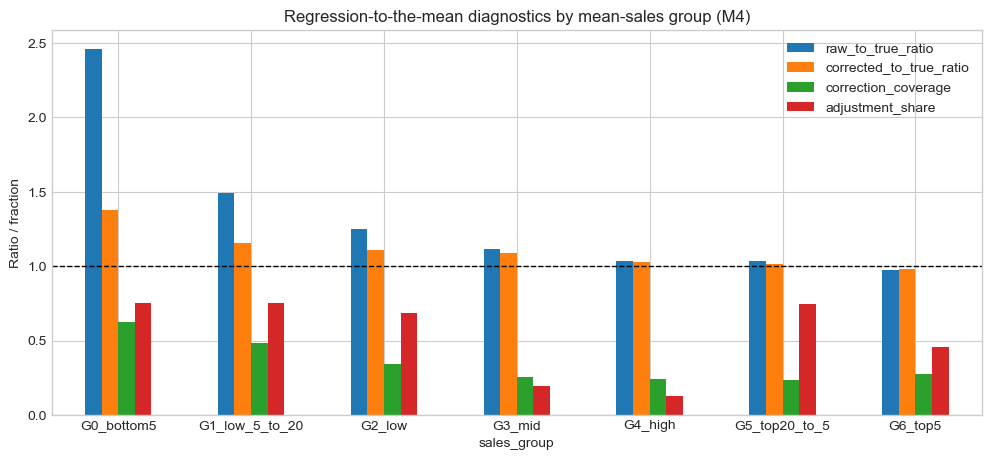

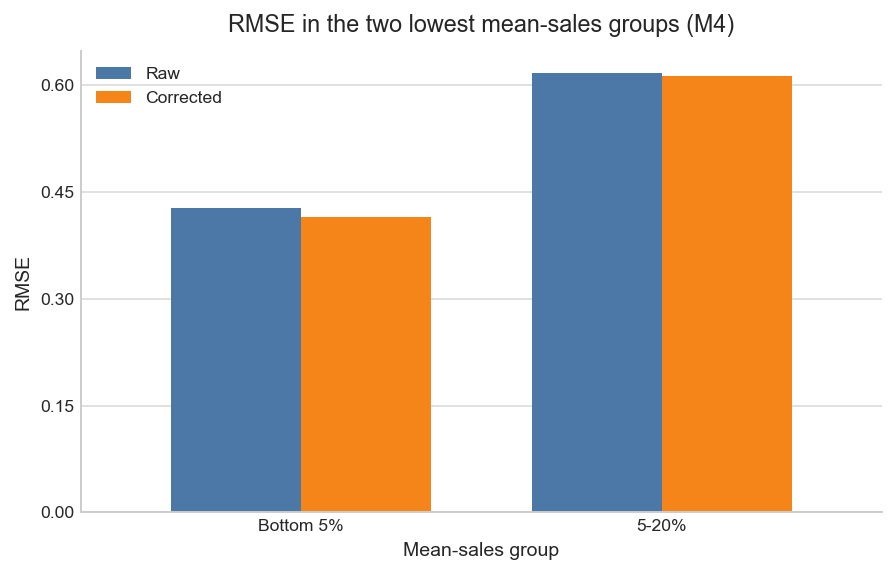

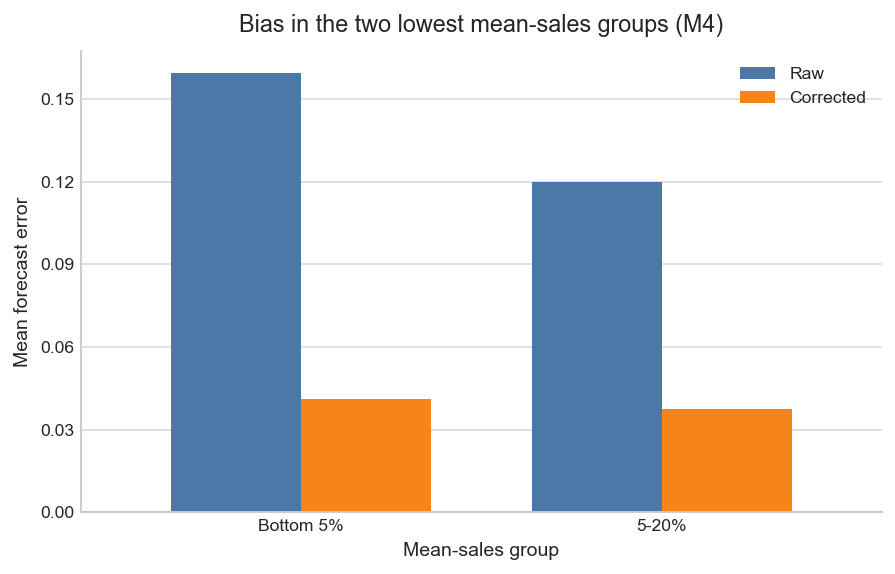

/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_71110/99938465.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,sales_group,raw_wrmse,corrected_wrmse
sales_group_label,,,
Bottom 5%,G0_bottom5,0.431407,0.419183
5-20%,G1_low_5_to_20,0.632090,0.628027


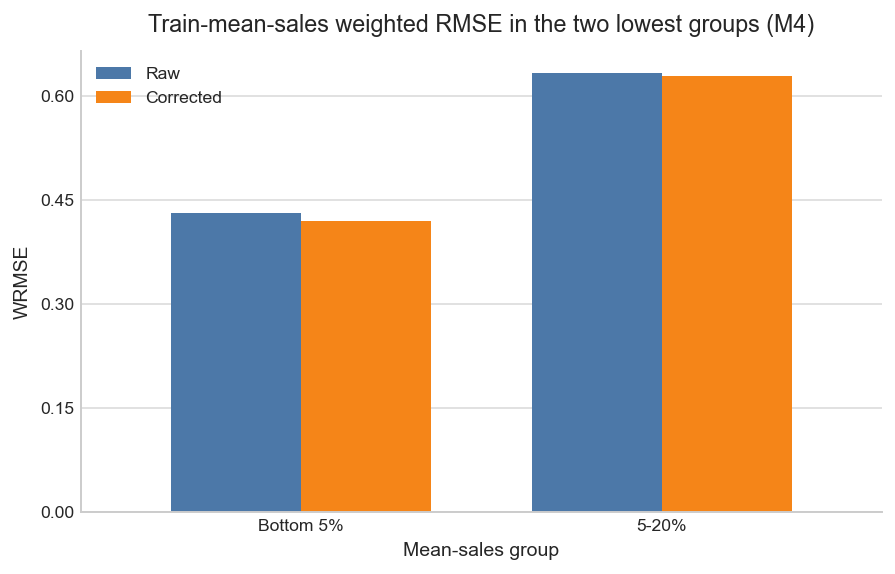

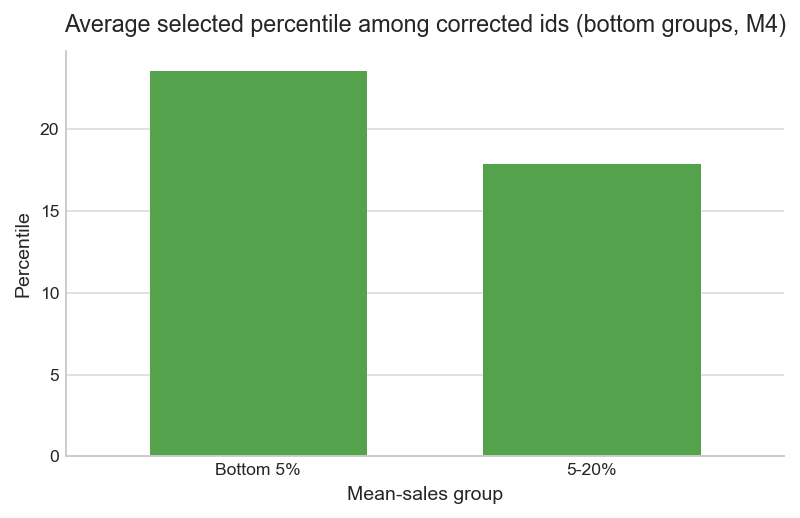

In [97]:
if group_summary.empty:
    print('group_summary is empty. Run the loop cell first.')
else:
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MaxNLocator

    plt.style.use('seaborn-v0_8-whitegrid')

    plot_groups = group_summary[group_summary['sales_group'] != 'ALL'].copy()
    bottom_groups = [g for g in group_order[:2] if g in set(plot_groups['sales_group'].astype(str))]
    bottom_group_labels = {
        'G0_bottom5': 'Bottom 5%',
        'G1_low_5_to_20': '5-20%',
    }

    raw_color = '#4C78A8'
    corrected_color = '#F58518'
    grid_color = '#D9D9D9'

    def scientific_barplot(ax, data, title, ylabel, hline=None):
        data.plot(kind='bar', ax=ax, color=[raw_color, corrected_color], width=0.72)
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel('Mean-sales group', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.tick_params(axis='x', rotation=0, labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.grid(axis='y', color=grid_color, linewidth=0.8)
        ax.grid(axis='x', visible=False)
        if hline is not None:
            ax.axhline(hline, color='#333333', linestyle='--', linewidth=1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(frameon=False, fontsize=9)

    ax = plot_groups.set_index('sales_group')[['true_sum', 'raw_sum', 'corrected_sum']].plot(kind='bar', figsize=(12, 5))
    ax.set_title('Forecast sum vs true sum by mean-sales group (M4)')
    ax.set_ylabel('Average sum over test windows')
    plt.xticks(rotation=0)
    plt.show()

    ax = plot_groups.set_index('sales_group')[['raw_to_true_ratio', 'corrected_to_true_ratio', 'correction_coverage', 'adjustment_share']].plot(kind='bar', figsize=(12, 5))
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_title('Regression-to-the-mean diagnostics by mean-sales group (M4)')
    ax.set_ylabel('Ratio / fraction')
    plt.xticks(rotation=0)
    plt.show()

    if not bottom_groups:
        print('No bottom sales groups found. Run the loop and aggregation cells first.')
    else:
        bottom_summary = plot_groups[plot_groups['sales_group'].astype(str).isin(bottom_groups)].copy()
        bottom_summary['sales_group_label'] = bottom_summary['sales_group'].astype(str).map(bottom_group_labels).fillna(bottom_summary['sales_group'].astype(str))
        bottom_summary = bottom_summary.set_index('sales_group_label')

        fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
        scientific_barplot(
            ax,
            bottom_summary[['raw_rmse', 'corrected_rmse']].rename(columns={'raw_rmse': 'Raw', 'corrected_rmse': 'Corrected'}),
            'RMSE in the two lowest mean-sales groups (M4)',
            'RMSE',
        )
        fig.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
        scientific_barplot(
            ax,
            bottom_summary[['raw_bias', 'corrected_bias']].rename(columns={'raw_bias': 'Raw', 'corrected_bias': 'Corrected'}),
            'Bias in the two lowest mean-sales groups (M4)',
            'Mean forecast error',
            hline=0.0,
        )
        fig.tight_layout()
        plt.show()

        if not forecast_eval_df.empty and not train_history_df.empty:
            weight_df = (
                train_history_df.assign(unique_id=lambda d: d['unique_id'].astype(str))
                .groupby(['fold', 'unique_id'], as_index=False)
                .agg(train_mean_sales=('train_mean_sales', 'mean'))
            )
            wrmse_df = forecast_eval_df.merge(weight_df, on=['fold', 'unique_id'], how='left')
            wrmse_df = wrmse_df[wrmse_df['sales_group'].astype(str).isin(bottom_groups)].copy()
            wrmse_df['weight'] = wrmse_df['train_mean_sales'].clip(lower=0).fillna(0)
            if wrmse_df['weight'].sum() == 0:
                wrmse_df['weight'] = 1.0
            wrmse_df['raw_sq_err'] = (wrmse_df['raw_pred'] - wrmse_df['y']) ** 2
            wrmse_df['corrected_sq_err'] = (wrmse_df['corrected_pred'] - wrmse_df['y']) ** 2

            bottom_wrmse = (
                wrmse_df.groupby('sales_group', observed=True)
                .apply(lambda g: pd.Series({
                    'raw_wrmse': np.sqrt(np.average(g['raw_sq_err'], weights=g['weight'])),
                    'corrected_wrmse': np.sqrt(np.average(g['corrected_sq_err'], weights=g['weight'])),
                }))
                .reset_index()
            )
            bottom_wrmse['sales_group_label'] = bottom_wrmse['sales_group'].astype(str).map(bottom_group_labels).fillna(bottom_wrmse['sales_group'].astype(str))
            bottom_wrmse = bottom_wrmse.set_index('sales_group_label')
            display(bottom_wrmse)

            fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
            scientific_barplot(
                ax,
                bottom_wrmse[['raw_wrmse', 'corrected_wrmse']].rename(columns={'raw_wrmse': 'Raw', 'corrected_wrmse': 'Corrected'}),
                'Train-mean-sales weighted RMSE in the two lowest groups (M4)',
                'WRMSE',
            )
            fig.tight_layout()
            plt.show()
        else:
            print('forecast_eval_df or train_history_df is empty; cannot compute WRMSE.')

    if not selected_percentiles_df.empty and not group_correction_df.empty:
        percentile_by_group = (
            group_correction_df[
                group_correction_df['is_corrected']
                & group_correction_df['sales_group'].astype(str).isin(bottom_groups)
            ]
            .groupby('sales_group', observed=True, as_index=False)['selected_percentile']
            .mean()
        )
        if not percentile_by_group.empty:
            percentile_by_group['sales_group_label'] = percentile_by_group['sales_group'].astype(str).map(bottom_group_labels).fillna(percentile_by_group['sales_group'].astype(str))
            fig, ax = plt.subplots(figsize=(5.8, 3.8), dpi=140)
            percentile_by_group.set_index('sales_group_label')[['selected_percentile']].plot(
                kind='bar', ax=ax, legend=False, color='#54A24B', width=0.65
            )
            ax.set_title('Average selected percentile among corrected ids (bottom groups, M4)', fontsize=12, pad=10)
            ax.set_xlabel('Mean-sales group', fontsize=10)
            ax.set_ylabel('Percentile', fontsize=10)
            ax.tick_params(axis='x', rotation=0, labelsize=9)
            ax.tick_params(axis='y', labelsize=9)
            ax.grid(axis='y', color=grid_color, linewidth=0.8)
            ax.grid(axis='x', visible=False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            fig.tight_layout()
            plt.show()
